In [ ]:
# --- POLITE path bootstrap (auto-added) ---
# These notebooks live in notebooks/ but expect to run from the repo root so
# top-level imports (utils, obs_utils, caltools, poltools) and relative data
# paths (FITSDATA/...) resolve. Jupyter starts the kernel in the notebook's
# own directory, so hop up one level when that happens.
import os, sys
from pathlib import Path
_cwd = Path.cwd()
if _cwd.name == "notebooks":
    os.chdir(_cwd.parent)
_root = str(Path.cwd())
if _root not in sys.path:
    sys.path.insert(0, _root)
print("POLITE root:", _root)

# POLITE — Polarimetry Simulator Showcase: `poltools`
## Forward-modelling the dual-beam telescope chain & recovering Stokes parameters

**Software:** `poltools` v0.1.0 (sibling of `caltools`)  ·  **Date:** 2026-06-08
·  **Detector:** QHY268M (IMX571) on the CDK20

This notebook drives the **simulation half** of `poltools` end-to-end: it builds
a synthetic sky, pushes every source through the instrument's **Mueller forward
model**, renders 2-D detector frames with the measured QHY268M noise physics,
writes them as FITS, and then runs the *same* reduction path the real data will
use — detection, aperture photometry, HWP modulation, standard-star calibration,
and a publication-grade error budget — recovering the injected polarization.

The optical chain we model, in order:

$$
\text{Sky}\;\rightarrow\;\underbrace{\text{CDK20}}_{D=0.508\,\text{m},\,f/6.8}
\;\rightarrow\;\underset{\alpha}{\text{PWI4 rot}}\;\rightarrow\;\text{L3}_{\rm UV/IR}
\;\rightarrow\;\text{HWP}(\theta,\delta)\;\rightarrow\;\underbrace{\text{EFW}}_{B,V,R,\text{Clr},\text{Drk}}
\;\rightarrow\;\underbrace{\alpha\text{-BBO Savart}}_{18\,\text{mm},\ o/e\ \text{split}}\;\rightarrow\;
\underbrace{\text{QHY268M}}_{3.76\,\mu\text{m},\,0.224''/\text{px}}
$$

The **PWI4 Focuser/Rotator** (field angle $\alpha$) sits upstream of the L3 cut
filter and the HWP. The ZWO 5-slot **EFW** precedes the $\alpha$-BBO analyzer; an
ideal filter is a scalar $\times$ identity Mueller element, so it **commutes** and
does not change $q,u$. Because $\alpha$-BBO is **dispersive**, the $o/e$ beam
separation is **per filter** — this showcase runs in one band (Photometric V).

> **Provenance (CLAUDE.md).** Every reduction/error method invoked here lives in
> `poltools`, where each function's docstring cites its **Source A** (user-provided)
> or **Source B** (peer-reviewed) origin: Mueller calculus & ideal-HWP modulation
> (Masiero 2007 / DUSTPol), least-squares modulation (Magalhães et al. 1984 /
> SOLVEPOL; the project **default**), double-ratio (Tinbergen 1996 / SOLVEPOL;
> the flat-field-independent fallback for bad-flat nights), MAS debiasing
> (Plaszczyński 2014 / Montier II 2015), position-angle errors
> (Naghizadeh-Khouei & Clarke 1993), and the CMOS noise handling (Stockmans et al.;
> project `reduction.md`). `photutils` is an implementation library, not a method.

In [1]:
import os, glob, warnings

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.patches import Circle
from mpl_toolkits.axes_grid1 import make_axes_locatable

import astropy.io.fits as fits
from astropy.visualization import AsinhStretch, ImageNormalize, PercentileInterval
from IPython.display import Markdown, display

import poltools as pt
from poltools import plotting as pplt     # NB: poltools.plotting selects Agg for headless use
from poltools import calibration as cal
from poltools._types import BeamFlux
from poltools.photometry import _effective_n, _MEDIAN_VAR_INFLATION
from caltools import SensorConfig

# poltools.plotting forced the Agg backend (headless scripting); switch back to
# the inline backend so every figure renders in the notebook.
%matplotlib inline

pm = "±"
DARK = False
cdef   = 'hot_r' if DARK else 'hot'      # match reduction.ipynb colour convention
cdef_r = 'hot'   if DARK else 'hot_r'

SEED = 20260608
rng = np.random.default_rng(SEED)
np.set_printoptions(precision=4, suppress=True)
print(f"poltools {pt.__version__}  ·  seed {SEED}")

poltools 0.1.0  ·  seed 20260608


# ─── Step 0: Instrument configuration ───

A single frozen `PolConfig` is the one source of truth shared by the forward
model and the reducer — guaranteeing the simulator and the pipeline never drift
apart. The detector half comes from a `caltools.SensorConfig`, so the noise
model is the *same* one characterized in `reduction.ipynb`.

| Parameter | Symbol | Value | Source |
|---|---|---|---|
| Aperture / focal ratio | $D$, $f/\#$ | 0.508 m, $f/6.8$ | CDK20 |
| Plate scale | — | $0.224''/\mathrm{px}$ | QHY268M on CDK20 |
| Conversion gain | $G$ | $1.0\ e^-/\mathrm{ADU}$ | PTC (Mode 0, Gain 0) |
| Read noise | $\sigma_{\rm RON}$ | $3.5\ e^-$ | frame-diff (Mode 0, Gain 0) |
| Full well | — | $51{,}000\ e^-$ | PTC turnover |
| Field rotator | $\alpha$ | $0^\circ$ | PWI4 (constant/sequence) |
| EFW band | — | Photometric V | ZWO 5-slot |
| Dual-beam split | — | 60 px @ PA $0^\circ$ *(per filter)* | $\alpha$-BBO Savart 18 mm |
| HWP sequence | $\theta$ | $0^\circ,22.5^\circ,\dots,157.5^\circ$ (8) | minimal $q,u$ + LSQ |
| Retardance | $\delta$ | $180^\circ$ (ideal HWP) | — |

> The $\alpha$-BBO split is **dispersive**, so the 60-px separation is a **per-filter** placeholder here; real per-band `BEAMSEP`/`BEAMPA` are measured from flats / standard-star $o/e$ pairs (Source A).

In [2]:
# ── Detector (QHY268M / IMX571) — same model as reduction.ipynb ──
sensor = SensorConfig(nx=512, ny=512, pixel_size_um=3.76, gain_e_per_adu=1.0,
                      temperature_c=-10.0, sensor_name="QHY268M")

# ── 8-angle HWP sequence (spans q,u; supports double-ratio + LSQ cross-check) ──
ANGLES8 = tuple(i * 22.5 for i in range(8))

# α-BBO is dispersive -> per-filter Savart geometry. Register the ZWO 5-slot EFW
# and select one band; placeholder 60-px split (real BEAMSEP from flats, Source A).
SEP_PX, SHOW_FILTER = 60.0, "Photometric V"
cfg = pt.PolConfig(
    sensor=sensor,
    beam=pt.BeamGeometry(separation_px=SEP_PX, position_angle_deg=0.0),
    plate_scale_arcsec=0.224,
    hwp_angles_deg=ANGLES8,
    retardance_deg=180.0,
    instrument_rotator_deg=0.0,                  # PWI4 field rotator alpha
    filters=pt.default_efw_filters(SEP_PX),      # B, V, R, Clear, Dark
    read_noise_e=3.5,
    full_well_e=51000.0,
    readout_mode="Mode0", gain_setting=0,        # gain-mode provenance
).for_filter(SHOW_FILTER)                        # -> cfg.beam = this band's split

# ── exposure / observing parameters ──
EXPTIME, SEEING, SKY_E, BIAS = 20.0, 2.2, 80.0, 1000.0
R_AP, R_IN, R_OUT = 13.0, 18.0, 29.0             # aperture + sky annulus [px]

print("=" * 65)
print("  STEP 0: INSTRUMENT CONFIGURATION")
print("=" * 65)
print(f"  Detector:       {sensor.nx}x{sensor.ny} px, {sensor.pixel_size_um} um, "
      f"{cfg.plate_scale_arcsec}\"/px")
print(f"  Gain / RON:     {sensor.gain_e_per_adu} e-/ADU, {cfg.read_noise_e} e-  "
      f"[{cfg.readout_mode}, Gain {cfg.gain_setting}]")
print(f"  Full well:      {cfg.full_well_e:.0f} e-   (sat limit {cfg.sat_limit_e():.0f} e-)")
print(f"  PWI4 rotator:   alpha = {cfg.instrument_rotator_deg:.0f} deg")
print(f"  EFW band:       {cfg.filter_name}  (lambda_eff "
      f"{cfg.active_filter().eff_wavelength_nm:.0f} nm)")
print(f"  Beam split:     {cfg.beam.separation_px:.0f} px @ PA {cfg.beam.position_angle_deg:.0f} deg  (alpha-BBO, per filter)")
print(f"  HWP angles:     {', '.join(f'{a:g}' for a in cfg.hwp_angles_deg)} deg")
print(f"  Exposure:       {EXPTIME:.0f} s,  seeing {SEEING}\" (FWHM {cfg.fwhm_px(SEEING):.1f} px),  sky {SKY_E:.0f} e-/px")

  STEP 0: INSTRUMENT CONFIGURATION
  Detector:       512x512 px, 3.76 um, 0.224"/px
  Gain / RON:     1.0 e-/ADU, 3.5 e-  [Mode0, Gain 0]
  Full well:      51000 e-   (sat limit 51000 e-)
  PWI4 rotator:   alpha = 0 deg
  EFW band:       Photometric V  (lambda_eff 551 nm)
  Beam split:     60 px @ PA 0 deg  (alpha-BBO, per filter)
  HWP angles:     0, 22.5, 45, 67.5, 90, 112.5, 135, 157.5 deg
  Exposure:       20 s,  seeing 2.2" (FWHM 9.8 px),  sky 80 e-/px


### The EFW band registry (per-filter $\alpha$-BBO geometry)

The $\alpha$-BBO Savart split is **dispersive**, so each EFW band has its own
`BeamGeometry`. `PolConfig.filters` holds the registry; `cfg.for_filter(name)`
selects a band (sets `cfg.beam`), and `reduce_to_stokes` groups frames **by
filter first**, then by HWP angle. The per-band separations below are
**placeholders for illustration** — real values are measured from flats /
standard-star $o/e$ pairs (Source A) and are flagged `characterized=False`
until then.

In [3]:
# ── the ZWO 5-slot EFW registry (placeholders; per-band BEAMSEP from flats) ──
print(f"  {'EFW slot':14s} {'sep[px]':>8} {'PA[deg]':>8} {'lambda':>8}  characterized")
for f in cfg.filters:
    lam = "dark" if f.is_dark else (f"{f.eff_wavelength_nm:.0f}nm"
                                    if f.eff_wavelength_nm else "broad")
    print(f"  {f.name:14s} {f.beam.separation_px:8.1f} "
          f"{f.beam.position_angle_deg:8.0f} {lam:>8}  {f.characterized}")
print(f"\n  active band: {cfg.active_filter().name}  "
      f"-> cfg.beam separation {cfg.beam.separation_px:.0f} px")

  EFW slot        sep[px]  PA[deg]   lambda  characterized
  Photometric B      60.0        0    440nm  False
  Photometric V      60.0        0    551nm  False
  Photometric R      60.0        0    640nm  False
  Clear              60.0        0    broad  False
  Dark               60.0        0     dark  False

  active band: Photometric V  -> cfg.beam separation 60 px


# ─── Step 1: The Mueller forward model ───

Each source carries an astrophysical Stokes vector $\mathbf{S}=(I,Q,U,V)$. The
chain up to one analyzed ($\alpha$-BBO Savart) beam is the Mueller product

$$
\mathbf{S}' = \mathbf{M}_{\rm analyzer}\,\mathbf{M}_{\rm HWP}(\theta,\delta)\,
              \mathbf{R}_{\rm PWI4}(\alpha)\,\mathbf{S},
$$

where $\mathbf{R}_{\rm PWI4}(\alpha)$ is the PWI4 field rotation. The L3 and EFW
filters are ideal (scalar $\times$ identity) and commute, so they are omitted
here. For an **ideal half-wave plate** ($\delta=180^\circ$) the $\alpha$-BBO
plate's two beams come out as the textbook modulation (Masiero 2007, Source B;
DUSTPol §2.1, Source A):

$$
I'_{e} = \tfrac12\!\left[I + Q\cos4\theta + U\sin4\theta\right],\qquad
I'_{o} = \tfrac12\!\left[I - Q\cos4\theta - U\sin4\theta\right],
$$

so the normalized difference is a pure $4\theta$ wave whose amplitude **is** the
polarization:

$$
R(\theta)\equiv\frac{I'_e-I'_o}{I'_e+I'_o}=q\cos4\theta+u\sin4\theta,
\qquad q=Q/I,\ u=U/I.
$$

A **non-ideal** retardance scales the recovered linear signal by $(1-\cos\delta)/2$
— the $\delta\!\neq\!180^\circ$ depolarization — which we verify numerically below.

In [4]:
# ── 1a. oe_intensities reproduces the ideal-HWP modulation exactly ──
p_in, th_in = 0.030, 30.0                         # 3% at 30 deg
q_in, u_in = p_in*np.cos(2*np.deg2rad(th_in)), p_in*np.sin(2*np.deg2rad(th_in))
S = pt.stokes_vector(1.0, q_in, u_in)
print(f"injected:  q={q_in:+.4f}  u={u_in:+.4f}  (p={p_in:.3%}, theta={th_in:.0f} deg)\n")

print(f"  {'theta':>6}  {'I_o':>8} {'I_e':>8}  {'R (sim)':>9}  {'R (ideal)':>10}  {'|diff|':>8}")
max_diff = 0.0
for th in np.arange(0, 180, 22.5):
    Io, Ie = pt.oe_intensities(S, th)
    R_sim = (Ie - Io) / (Ie + Io)
    R_ideal = q_in*np.cos(4*np.deg2rad(th)) + u_in*np.sin(4*np.deg2rad(th))
    max_diff = max(max_diff, abs(R_sim - R_ideal))
    print(f"  {th:6.1f}  {Io:8.4f} {Ie:8.4f}  {R_sim:+9.4f}  {R_ideal:+10.4f}  {abs(R_sim-R_ideal):8.1e}")
print(f"\n  flux conservation  I_o+I_e = {Io+Ie:.6f}  (= I)")
print(f"  max |R_sim - R_ideal| over the sequence = {max_diff:.2e}  -> forward model is exact")

injected:  q=+0.0150  u=+0.0260  (p=3.000%, theta=30 deg)

   theta       I_o      I_e    R (sim)   R (ideal)    |diff|
     0.0    0.4925   0.5075    +0.0150     +0.0150   4.5e-17
    22.5    0.4870   0.5130    +0.0260     +0.0260   3.8e-17
    45.0    0.5075   0.4925    -0.0150     -0.0150   4.2e-17
    67.5    0.5130   0.4870    -0.0260     -0.0260   4.2e-17
    90.0    0.4925   0.5075    +0.0150     +0.0150   3.8e-17
   112.5    0.4870   0.5130    +0.0260     +0.0260   4.2e-17
   135.0    0.5075   0.4925    -0.0150     -0.0150   3.5e-17
   157.5    0.5130   0.4870    -0.0260     -0.0260   4.5e-17

  flux conservation  I_o+I_e = 1.000000  (= I)
  max |R_sim - R_ideal| over the sequence = 4.51e-17  -> forward model is exact


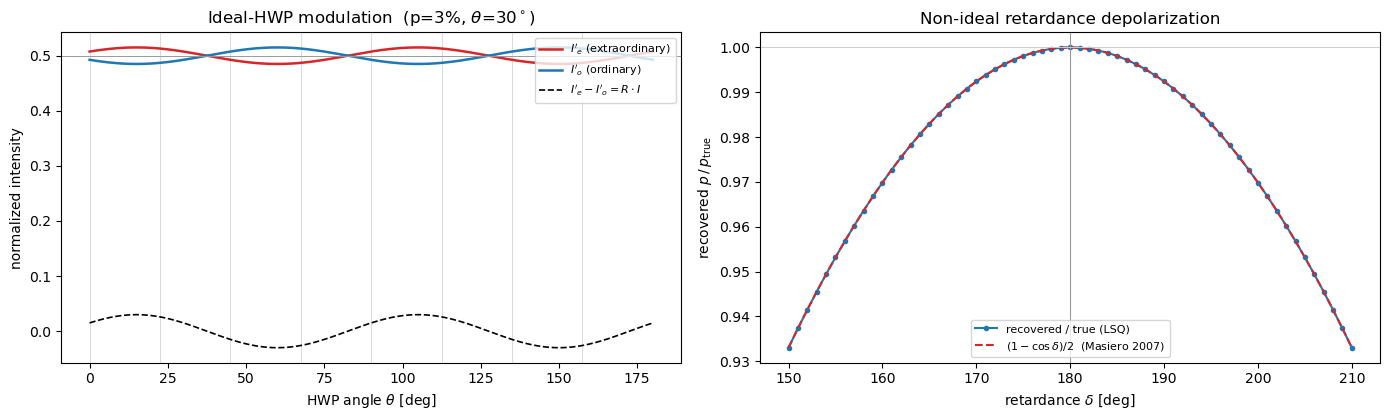

In [5]:
# ── 1b. Modulation curve + non-ideal-retardance depolarization ──
fig, axes = plt.subplots(1, 2, figsize=(14, 4.3))

# left: the analytic o/e intensities and R(theta) for the ideal HWP
th = np.linspace(0, 180, 400)
Io = 0.5*(1 - q_in*np.cos(4*np.deg2rad(th)) - u_in*np.sin(4*np.deg2rad(th)))
Ie = 0.5*(1 + q_in*np.cos(4*np.deg2rad(th)) + u_in*np.sin(4*np.deg2rad(th)))
axes[0].plot(th, Ie, 'C3-', lw=1.8, label=r"$I'_e$ (extraordinary)")
axes[0].plot(th, Io, 'C0-', lw=1.8, label=r"$I'_o$ (ordinary)")
axes[0].plot(th, Ie - Io, 'k--', lw=1.2, label=r"$I'_e-I'_o = R\cdot I$")
for a in ANGLES8:
    axes[0].axvline(a, color='0.85', lw=0.7, zorder=0)
axes[0].axhline(0.5, color='0.6', lw=0.7)
axes[0].set_xlabel(r"HWP angle $\theta$ [deg]"); axes[0].set_ylabel("normalized intensity")
axes[0].set_title(f"Ideal-HWP modulation  (p={p_in:.0%}, "+r"$\theta$="+f"{th_in:.0f}"+r"$^\circ$)")
axes[0].legend(fontsize=8, loc="upper right")

# right: recovered p / true p as the retardance departs from 180 deg
deltas = np.linspace(150, 210, 61)
rec_frac = []
for d in deltas:
    bfs = []
    for a in ANGLES8:
        io, ie = pt.oe_intensities(S, a, retardance_deg=d)
        bfs.append(BeamFlux(a, io, ie, 0.0, 0.0))   # noiseless
    B = pt.lsq_modulation(bfs)
    rec_frac.append(np.hypot(B["q"], B["u"]) / p_in)
axes[1].plot(deltas, rec_frac, 'C0o-', ms=3, label="recovered / true (LSQ)")
axes[1].plot(deltas, (1 - np.cos(np.deg2rad(deltas)))/2, 'C3--', lw=1.5,
             label=r"$(1-\cos\delta)/2$  (Masiero 2007)")
axes[1].axvline(180, color='0.6', lw=0.8); axes[1].axhline(1.0, color='0.8', lw=0.7)
axes[1].set_xlabel(r"retardance $\delta$ [deg]"); axes[1].set_ylabel(r"recovered $p\,/\,p_{\rm true}$")
axes[1].set_title("Non-ideal retardance depolarization")
axes[1].legend(fontsize=8, loc="lower center")
plt.tight_layout(); plt.show()

# ─── Step 2: Rendering one detector frame ───

`poltools.simulate.render_frame` turns the forward model into pixels. For each
source it splits the flux into the two beams, lays down a Gaussian PSF for each
(seeing $\to$ px via the plate scale, **origin upper-left**), and then injects the
QHY268M detector physics measured in `reduction.ipynb`, in physical order:

1. **sky** background (e⁻/px), optional **PRNU** multiplicative response;
2. **dark** accumulation ($\dot{D}\,t$, or a 2-D master dark with FPN/hot pixels);
3. **full-well clipping** at $51\,\mathrm{ke^-}$;
4. **Poisson** shot noise, then Gaussian **read noise**;
5. **gain**, **bias** pedestal, 16-bit quantization, and the `BZERO=32768`
   unsigned-int convention — making the output **byte-compatible** with frames
   the real camera writes.

frame dtype=uint16, shape=(512, 512), range 1040-28958 ADU
truth o-beam @ (x=256, y=230)  f_o=2.955e+06 e-
truth e-beam @ (x=256, y=290)  f_e=3.045e+06 e-
e/o flux ratio = 1.0305  (>1 -> +Q' at theta=0, q=+0.015)


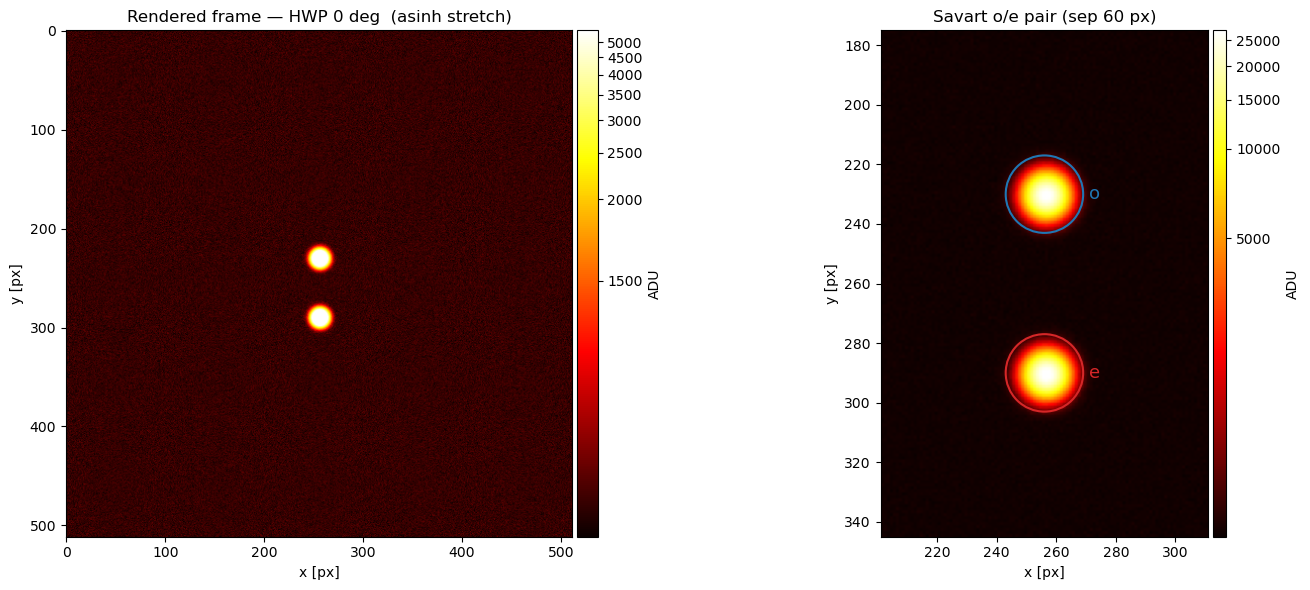

In [6]:
# ── 2a. one bright source, one HWP angle, with ground truth returned ──
demo_scene = pt.make_scene([(256.0, 230.0)], [(1.0, q_in, u_in, 0.0)],
                           [6.0e6], names=["demo"])
frame, truth = pt.render_frame(demo_scene, cfg, hwp_deg=0.0, exptime_s=EXPTIME,
                               seeing_arcsec=SEEING, sky_e_per_px=SKY_E, rng=rng,
                               shape=(512, 512), bias_adu=BIAS, return_truth=True)
src = truth["sources"][0]
print(f"frame dtype={frame.dtype}, shape={frame.shape}, "
      f"range {frame.min()}-{frame.max()} ADU")
print(f"truth o-beam @ (x={src['x_o']:.0f}, y={src['y_o']:.0f})  f_o={src['f_o']:.3e} e-")
print(f"truth e-beam @ (x={src['x_e']:.0f}, y={src['y_e']:.0f})  f_e={src['f_e']:.3e} e-")
print(f"e/o flux ratio = {src['f_e']/src['f_o']:.4f}  (>1 -> +Q' at theta=0, q={q_in:+.3f})")

# ── 2b. display: full frame (origin upper-left) + zoom on the o/e pair ──
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
norm = ImageNormalize(frame, interval=PercentileInterval(99.7), stretch=AsinhStretch(a=0.02))
im0 = axes[0].imshow(frame, origin='upper', cmap=cdef, norm=norm)
axes[0].set_title("Rendered frame — HWP 0 deg  (asinh stretch)")
axes[0].set_xlabel("x [px]"); axes[0].set_ylabel("y [px]")
divider = make_axes_locatable(axes[0]); cax = divider.append_axes("right", size="4%", pad=0.05)
fig.colorbar(im0, cax=cax, label="ADU")

xo, yo, xe, ye = src['x_o'], src['y_o'], src['x_e'], src['y_e']
half = 55
zy = slice(int(yo)-half, int(ye)+half); zx = slice(int(xo)-half, int(xo)+half)
sub = frame[zy, zx]
im1 = axes[1].imshow(sub, origin='upper', cmap=cdef,
                     extent=[zx.start, zx.stop, zy.stop, zy.start],
                     norm=ImageNormalize(sub, interval=PercentileInterval(99.9), stretch=AsinhStretch(a=0.02)))
for (cx, cy, lab, col) in [(xo, yo, "o", "C0"), (xe, ye, "e", "C3")]:
    axes[1].add_patch(Circle((cx, cy), R_AP, fill=False, ec=col, lw=1.5))
    axes[1].text(cx+R_AP+2, cy, lab, color=col, fontsize=13, va="center")
axes[1].set_title(f"Savart o/e pair (sep {cfg.beam.separation_px:.0f} px)")
axes[1].set_xlabel("x [px]"); axes[1].set_ylabel("y [px]")
divider = make_axes_locatable(axes[1]); cax = divider.append_axes("right", size="4%", pad=0.05)
fig.colorbar(im1, cax=cax, label="ADU")
plt.tight_layout(); plt.show()

# ─── Step 3: The full HWP sequence → FITS ───

We now build a small science field spanning the four target regimes the pipeline
must handle, plus the **standard stars** used for calibration, and render the
complete 8-angle sequence to disk. Each frame is a real FITS file carrying the
polarimetry header block (`HWPANG`, `RETARD`, `INSTROT`, `POLSEQ/POLSEQN`,
`POLEFF`, `BEAMSEP/BEAMPA`, …), so the grouping/reduction code below is exercising
the *acquisition format*, not a shortcut.

We also inject the systematics calibration must later remove: an instrumental
polarization $(q_0,u_0)$ and a modulation efficiency $\eta<1$.

In [7]:
# ── 3a. the science field + standards (ground truth) ──
# (name, x, y, p, theta_deg, total_flux_e, role, p_lit)
FIELD = [
    ("stellar_eps_aur", 110,  90, 0.030,  30.0, 5.0e6, "science", None),
    ("ism_dust",        300,  90, 0.015, 120.0, 4.0e6, "science", None),
    ("asteroid",        110, 250, 0.005,  75.0, 7.0e6, "science", None),
    ("supernova",       300, 250, 0.003, 160.0, 8.0e6, "science", None),
    ("sne_faint",       205, 170, 0.005,  45.0, 3.0e5, "science", None),   # low SNR
    ("unpol_std_1",     420,  90, 0.000,   0.0, 6.0e6, "unpol",   0.0),
    ("unpol_std_2",     420, 250, 0.000,   0.0, 6.0e6, "unpol",   0.0),
    ("highpol_std",     205, 360, 0.050,  90.0, 6.0e6, "polstd",  0.050),
]
IP_TRUE, EFF_TRUE = (0.004, -0.003), 0.97          # to be recovered by calibration

def truth_qu(p, th):
    a = np.deg2rad(th)
    return p*np.cos(2*a), p*np.sin(2*a)

positions, names = [], []
stokes, fluxes = [], []
for nm, x, y, p, th, fl, role, plit in FIELD:
    q, u = truth_qu(p, th)
    positions.append((float(x), float(y))); names.append(nm)
    stokes.append((1.0, q, u, 0.0)); fluxes.append(fl)
scene = pt.make_scene(positions, stokes, fluxes, names)

# ── 3b. render the full HWP sequence to FITS ──
OUT_FITS = "FITSDATA/SIM_20260608"
paths = pt.simulate_sequence(
    scene, cfg, out_dir=OUT_FITS, exptime_s=EXPTIME, seeing_arcsec=SEEING,
    sky_e_per_px=SKY_E, rng=rng, shape=(512, 512), object_name="SHOWCASE",
    ip=IP_TRUE, efficiency=EFF_TRUE, bias_adu=BIAS,
)
print(f"wrote {len(paths)} FITS frames -> {OUT_FITS}/")
for p in paths:
    print("   ", os.path.basename(str(p)))

wrote 8 FITS frames -> FITSDATA/SIM_20260608/
    SIM_00_hwp000.0.fit
    SIM_01_hwp022.5.fit
    SIM_02_hwp045.0.fit
    SIM_03_hwp067.5.fit
    SIM_04_hwp090.0.fit
    SIM_05_hwp112.5.fit
    SIM_06_hwp135.0.fit
    SIM_07_hwp157.5.fit


  SIM_00_hwp000.0.fit
  ----------------------------------------------------
  OBJECT   =     SHOWCASE   / Target name
  INSTRUME =      QHY268M   / Instrument/sensor name
  EXPTIME  =         20.0   / Exposure time [s]
  FILTER   = Photometric V   / Filter name
  WAVELEN  =        551.0   / Filter effective wavelength [nm]
  EGAIN    =          1.0   / Conversion gain [e-/ADU]
  PIXSCALE =        0.224   / Plate scale [arcsec/pixel]
  HWPANG   =          0.0   / Half-wave-plate angle [deg]
  RETARD   =        180.0   / Retarder retardance delta [deg]
  INSTROT  =          0.0   / PWI4 field-rotator angle [deg]
  POLBEAM  =         dual   / Beam(s) recorded (o/e/dual)
  POLSEQ   =          SIM   / Polarimetry sequence identifier
  POLSEQN  =            0   / Index within polarimetry sequence
  POLEFF   =         0.97   / Polarization (modulation) efficiency
  BEAMSEP  =         60.0   / o<->e beam separation [px]
  BEAMPA   =          0.0   / o->e split position angle [deg]
  SAVMAT   

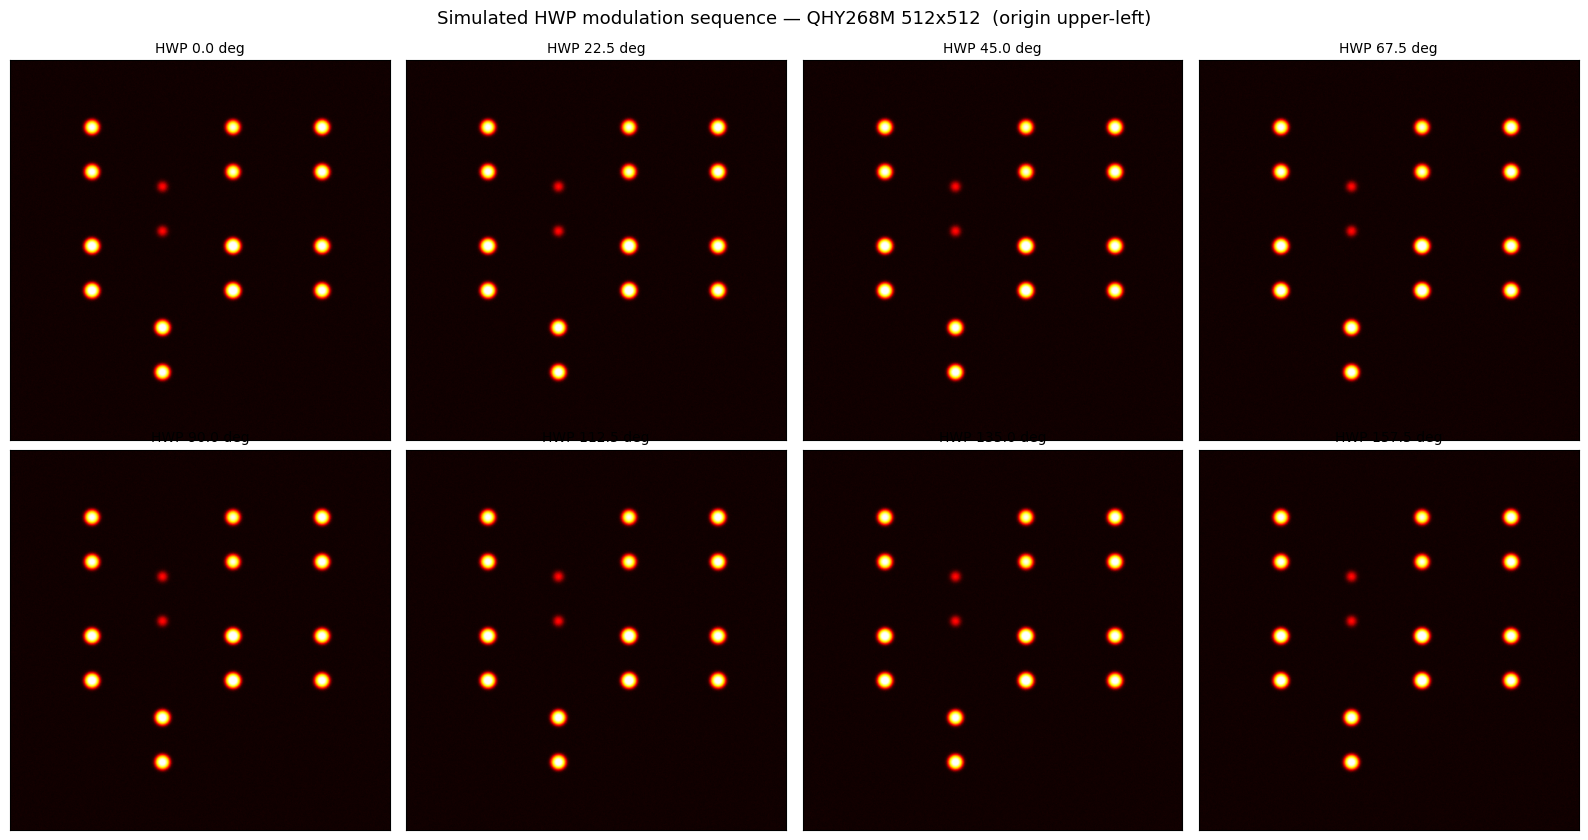

In [8]:
# ── 3c. the polarimetry header block of one frame ──
hdr = fits.getheader(str(paths[0]))
print(f"  {os.path.basename(str(paths[0]))}\n  " + "-"*52)
for kw in ["OBJECT", "INSTRUME", "EXPTIME", "FILTER", "WAVELEN", "EGAIN",
           "PIXSCALE", "HWPANG", "RETARD", "INSTROT", "POLBEAM", "POLSEQ",
           "POLSEQN", "POLEFF", "BEAMSEP", "BEAMPA", "SAVMAT", "SAVTHK", "BZERO"]:
    if kw in hdr:
        print(f"  {kw:9s}= {str(hdr[kw]):>12}   / {hdr.comments[kw]}")

# ── 3d. montage of all 8 HWP angles (full field) ──
fig, axes = plt.subplots(2, 4, figsize=(16, 8.4))
for ax, p in zip(axes.ravel(), paths):
    data, ang, _ = pt.read_pol_frame(str(p))
    n = ImageNormalize(data, interval=PercentileInterval(99.6), stretch=AsinhStretch(a=0.03))
    ax.imshow(data, origin='upper', cmap=cdef, norm=n)
    ax.set_title(f"HWP {ang:.1f} deg", fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("Simulated HWP modulation sequence — QHY268M 512x512  (origin upper-left)",
             fontsize=13, y=0.995)
plt.tight_layout(); plt.show()

# ─── Step 4: Detection & o/e pairing ───

The reducer can take known positions (as here, since we injected them) or find
sources itself. We demonstrate the automatic path: `DAOStarFinder` (photutils)
detects every beam, and `pair_oe` matches each ordinary beam to its extraordinary
partner using the known Savart offset vector $(\Delta x,\Delta y)$.

detected 16 beams -> 8 o/e pairs (truth: 8 sources, faint SNe may fall below 8 sigma)


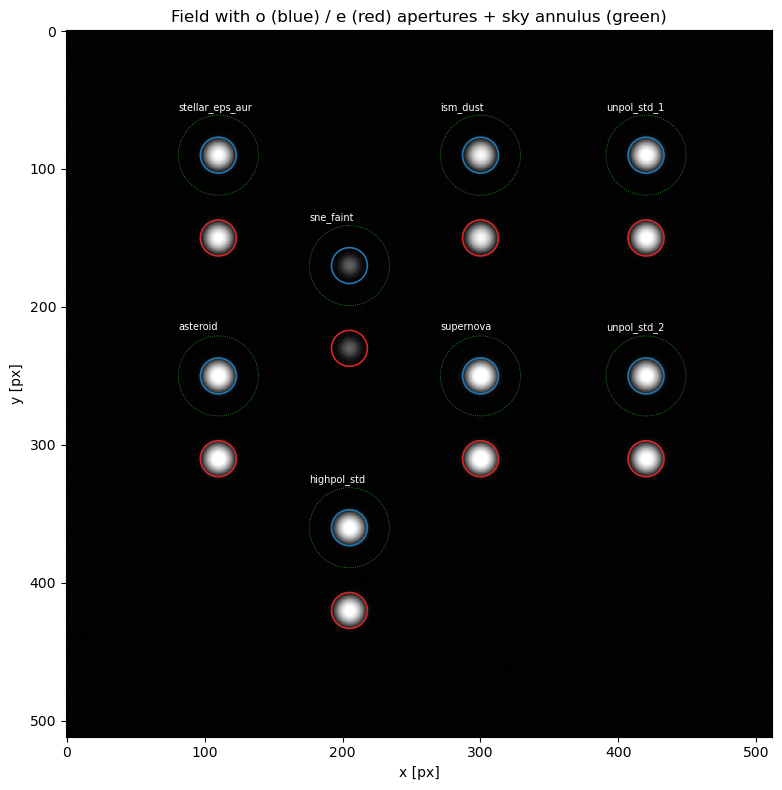

In [9]:
# ── 4a. detect on the reference (HWP 0) frame + pair o/e by the beam offset ──
frames_by_angle = {}
for p in paths:
    data, ang, _ = pt.read_pol_frame(str(p))
    frames_by_angle[round(ang, 3)] = data
ref = frames_by_angle[0.0]

det = pt.detect_sources(ref, cfg.fwhm_px(SEEING), threshold_sigma=8.0)
pairs = pt.pair_oe(det, cfg.beam)
print(f"detected {0 if det is None else len(det)} beams -> {len(pairs)} o/e pairs "
      f"(truth: {len(positions)} sources, faint SNe may fall below 8 sigma)")

# ── 4b. overlay apertures (o = blue, e = red) and sky annuli on the field ──
dx, dy = cfg.beam.offset_xy()
fig, ax = plt.subplots(figsize=(8.5, 8))
norm = ImageNormalize(ref, interval=PercentileInterval(99.6), stretch=AsinhStretch(a=0.03))
ax.imshow(ref, origin='upper', cmap='gray', norm=norm)
for (x, y), nm in zip(positions, names):
    ax.add_patch(Circle((x, y), R_AP, fill=False, ec="C0", lw=1.2))
    ax.add_patch(Circle((x+dx, y+dy), R_AP, fill=False, ec="C3", lw=1.2))
    ax.add_patch(Circle((x, y), R_OUT, fill=False, ec="C2", lw=0.6, ls=":"))
    ax.text(x-R_OUT, y-R_OUT-4, nm, color="w", fontsize=7)
ax.set_title("Field with o (blue) / e (red) apertures + sky annulus (green)")
ax.set_xlabel("x [px]"); ax.set_ylabel("y [px]")
plt.tight_layout(); plt.show()

# ─── Step 5: Aperture photometry across angles ───

`photometer_sequence` measures the $o$ and $e$ flux of every source at every HWP
angle with concentric `CircularAperture` / `CircularAnnulus` photometry
(photutils), returning electrons with CCD-equation uncertainties. The recovered
$R(\theta)=(F_e-F_o)/(F_e+F_o)$ should trace the $q\cos4\theta+u\sin4\theta$ wave
— with amplitude set by $p$ and phase set by $\theta$.

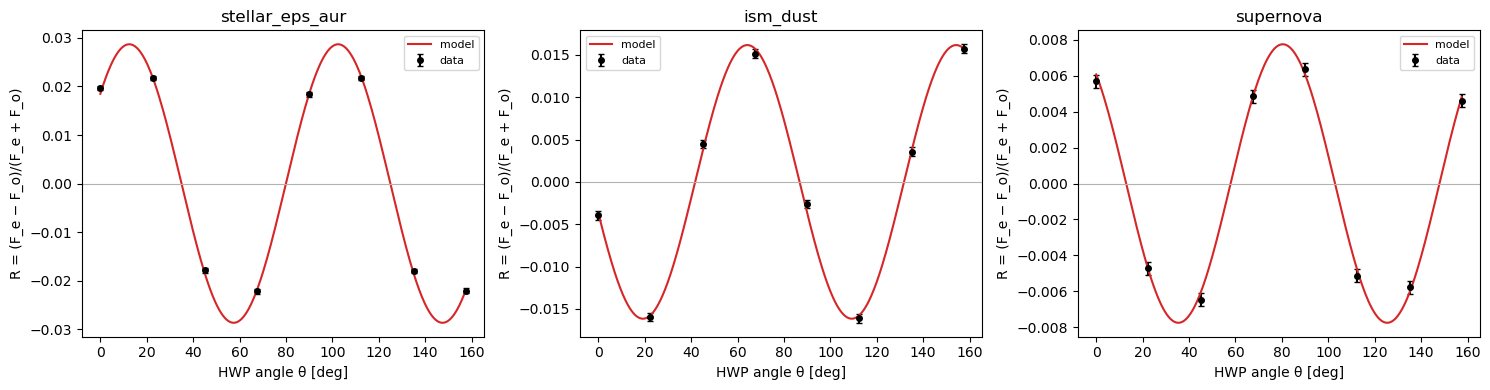

In [10]:
# ── 5a. aperture photometry of every source across the 8 angles ──
flux_by_src = pt.photometer_sequence(
    frames_by_angle, cfg, positions, names,
    r_ap=R_AP, r_in=R_IN, r_out=R_OUT, bias_adu=BIAS,
)
# ── 5b. measured modulation curves for three representative regimes (LSQ fit) ──
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, nm in zip(axes, ["stellar_eps_aur", "ism_dust", "supernova"]):
    B = pt.lsq_modulation(flux_by_src[nm])
    pplt.plot_modulation_curve(flux_by_src[nm], B["q"], B["u"], ax=ax, title=nm)
plt.tight_layout(); plt.show()

# ─── Step 6: Modulation → q, u ───

Two literature reductions, run side by side:

**Least-squares modulation (default, $N\!\ge\!4$).** Fit
$z_i=q\cos4\psi_i+u\sin4\psi_i$ by weighted linear least squares
(Magalhães et al. 1984; SOLVEPOL, Source B) over **every** HWP angle in the
sequence, yielding the $(q,u)$ covariance, a per-fit $\chi^2$ goodness-of-fit,
and the SOLVEPOL residual $\sigma_P$ cross-check — the richest diagnostics. This
is the **project default** (`reduce_to_stokes(..., method="lsq")`). Because the
fit is on $z=(F_e-F_o)/(F_e+F_o)$, it assumes the $o/e$ beams are matched:
pixel-to-pixel response (PRNU) between the two aperture positions does **not**
cancel, so real frames must be **flat-fielded first** with
the night's master skyflat.

**Double-ratio (fallback for bad-flat nights).** With $r(\theta)=F_e/F_o$ and
$RR_q=r(0^\circ)/r(45^\circ)$,
$$
q=\frac{\sqrt{RR_q}-1}{\sqrt{RR_q}+1},\qquad
u=\frac{\sqrt{RR_u}-1}{\sqrt{RR_u}+1},\quad RR_u=\frac{r(22.5^\circ)}{r(67.5^\circ)}.
$$
The per-beam throughput cancels **exactly** in the ratio-of-ratios (Tinbergen 1996;
SOLVEPOL, Source B) — immune to flat-field and seeing differences. Select it with
`method="double_ratio"` when the night's skyflats are unusable (requires the
4-angle set $\{0, 22.5, 45, 67.5\}^\circ$).

In [11]:
# ── 6a. least-squares (default) vs double-ratio (bad-flat fallback) per source ──
raw_lsq, raw_dr = {}, {}
print(f"  {'source':16s} {'LSQ q,u (default)':>20}  {'chi2/dof':>10}   {'double-ratio q,u':>20}")
for nm in names:
    bfs = flux_by_src[nm]
    a = pt.lsq_modulation(bfs); b = pt.double_ratio(bfs)
    raw_lsq[nm], raw_dr[nm] = a, b
    print(f"  {nm:16s}  q={a['q']:+.4f} u={a['u']:+.4f}  {a['chi2']:6.1f}/{a['dof']}    "
          f"q={b['q']:+.4f} u={b['u']:+.4f}")
print("\n  (uncalibrated: values still carry the injected IP and efficiency)")

  source              LSQ q,u (default)    chi2/dof       double-ratio q,u
  stellar_eps_aur   q=+0.0185 u=+0.0220    10.3/6    q=+0.0188 u=+0.0220
  ism_dust          q=-0.0037 u=-0.0157     9.4/6    q=-0.0042 u=-0.0155
  asteroid          q=-0.0003 u=-0.0004    10.9/6    q=-0.0004 u=-0.0005
  supernova         q=+0.0061 u=-0.0048     4.8/6    q=+0.0061 u=-0.0048
  sne_faint         q=+0.0046 u=+0.0030     6.7/6    q=+0.0045 u=+0.0021
  unpol_std_1       q=+0.0037 u=-0.0028    12.2/6    q=+0.0033 u=-0.0029
  unpol_std_2       q=+0.0039 u=-0.0031    10.0/6    q=+0.0041 u=-0.0028
  highpol_std       q=-0.0444 u=-0.0029     0.7/6    q=-0.0444 u=-0.0029

  (uncalibrated: values still carry the injected IP and efficiency)


# ─── Step 7: Calibration from standard stars ───

The Mueller chain is inverted with standards (Masiero 2007 §3; Serkowski 1974):

- **Instrumental polarization** $(q_0,u_0)$ — the mean $q,u$ of *unpolarized*
  standards (true $p\approx0$, so what's measured **is** the IP); subtracted in
  the $q$–$u$ plane.
- **Polarization efficiency** $\eta=\langle p_{\rm meas}/p_{\rm lit}\rangle$ — from
  a highly-polarized standard; $p$ is divided by it.

(A position-angle zero-point $\Delta\theta$ would come from polarized standards of
known $\theta_{\rm lit}$; here the simulated frame is already in the equatorial
frame, so $\Delta\theta=0$.)

In [12]:
# ── 7a. instrumental polarization from the two unpolarized standards ──
unpol = [nm for (nm, *_r, role, _p) in FIELD if role == "unpol"]
q0, u0, _cov = cal.fit_instrumental_polarization(
    [raw_lsq[nm]["q"] for nm in unpol], [raw_lsq[nm]["u"] for nm in unpol])

# ── 7b. efficiency from the high-pol standard (after IP removal) ──
p_lit = dict((f[0], f[7]) for f in FIELD)["highpol_std"]
qc, uc = cal.apply_ip(raw_lsq["highpol_std"]["q"], raw_lsq["highpol_std"]["u"], q0, u0)
eff = cal.fit_efficiency([np.hypot(qc, uc)], [p_lit])
calib = pt.PolCalibration(q0=q0, u0=u0, dtheta_deg=0.0, efficiency=eff)

print("=" * 65)
print("  STEP 7: STANDARD-STAR CALIBRATION")
print("=" * 65)
print(f"  fitted IP:     q0={q0:+.4f}  u0={u0:+.4f}")
print(f"  injected IP*eff: q0={EFF_TRUE*IP_TRUE[0]:+.4f}  u0={EFF_TRUE*IP_TRUE[1]:+.4f}  (what is measured)")
print(f"  fitted efficiency: {eff:.4f}   (injected {EFF_TRUE})")

  STEP 7: STANDARD-STAR CALIBRATION
  fitted IP:     q0=+0.0038  u0=-0.0029
  injected IP*eff: q0=+0.0039  u0=-0.0029  (what is measured)
  fitted efficiency: 0.9646   (injected 0.97)


# ─── Step 8: Calibrated Stokes + error budget ───

`assemble_stokes` turns calibrated $(q,u)$ into the reportable quantities with the
full publication error budget:

$$
p=\sqrt{q^2+u^2},\qquad \theta=\tfrac12\operatorname{atan2}(u,q)\in[0,180^\circ).
$$

Because $p$ is positive-definite it is **Rice-biased** at low SNR; the default
report is the **Modified Asymptotic** estimator (Plaszczyński 2014 eq. 20;
Montier II 2015):
$$
\hat p_{\rm MAS}=p-b^2\,\frac{1-e^{-p^2/b^2}}{2p},\qquad b^2=\sigma_p^2 .
$$
The position-angle error uses the Gaussian $\sigma_\theta=28.65^\circ\,\sigma_p/p$
at high SNR and the **Naghizadeh-Khouei & Clarke (1993)** confidence interval at
low SNR.

In [13]:
# ── 8a. calibrate -> assemble Stokes + errors for the science targets ──
science = [(nm, p, th) for (nm, x, y, p, th, fl, role, plit) in FIELD if role == "science"]
results, rows = [], []
for nm, p_true, th_true in science:
    qu = dict(raw_lsq[nm])
    qu["q"], qu["u"] = calib.apply(qu["q"], qu["u"])
    if eff not in (0.0, 1.0):
        qu["sigma_q"] /= eff; qu["sigma_u"] /= eff
        if "cov_qu" in qu:
            qu["cov_qu"] /= eff ** 2    # covariance carries 1/eta^2
    I0 = float(np.mean([b.f_o + b.f_e for b in flux_by_src[nm]]))
    res = pt.assemble_stokes(qu, I0=I0, name=nm, method="lsq", estimator="mas")
    results.append(res); rows.append((nm, p_true, th_true, res.scalar_summary))

# ── 8b. results table ──
hdr = ("| source | regime | p_inj | p_MAS | sigma_p | theta_inj | theta_rec | "
       "sigma_theta | SNR |\n|---|---|---|---|---|---|---|---|---|")
regime = {"stellar_eps_aur": "stellar few-%", "ism_dust": "ISM 1-5%",
          "asteroid": "solar-system", "supernova": "SNe sub-%", "sne_faint": "SNe low-SNR"}
lines = [hdr]
for nm, p_true, th_true, s in rows:
    lines.append(f"| {nm} | {regime[nm]} | {p_true:.3%} | {s['p_mas']:.3%} | "
                 f"{s['sigma_p']:.3%} | {th_true:.1f}° | {s['theta_deg']:.2f}° | "
                 f"{s['sigma_theta_deg']:.2f}° | {s['snr']:.1f} |")
display(Markdown("\n".join(lines)))

| source | regime | p_inj | p_MAS | sigma_p | theta_inj | theta_rec | sigma_theta | SNR |
|---|---|---|---|---|---|---|---|---|
| stellar_eps_aur | stellar few-% | 3.000% | 2.994% | 0.024% | 30.0° | 29.74° | 0.23° | 127.0 |
| ism_dust | ISM 1-5% | 1.500% | 1.538% | 0.026% | 120.0° | 119.87° | 0.49° | 58.2 |
| asteroid | solar-system | 0.500% | 0.501% | 0.020% | 75.0° | 73.96° | 1.13° | 25.2 |
| supernova | SNe sub-% | 0.300% | 0.304% | 0.019% | 160.0° | 159.97° | 1.75° | 16.4 |
| sne_faint | SNe low-SNR | 0.500% | 0.607% | 0.114% | 45.0° | 41.08° | 5.35° | 5.4 |

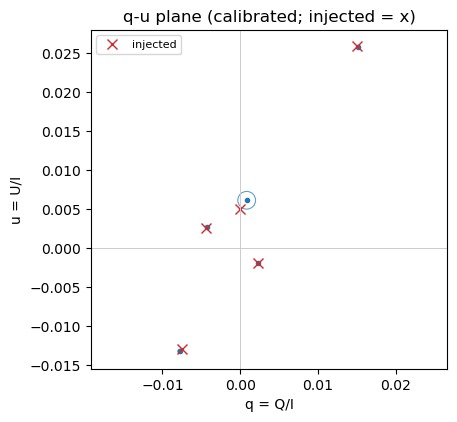

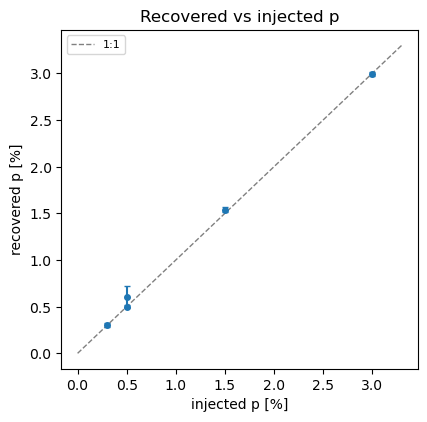

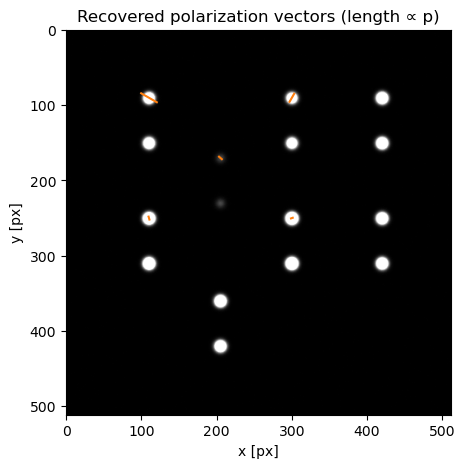

In [14]:
# ── 8c. publication figures: q-u plane, recovered-vs-injected, vector overlay ──
inj = [truth_qu(p, th) for (nm, p, th) in science]
ax = pplt.plot_qu_plane(results, injected=inj, title="q-u plane (calibrated; injected = x)")
plt.show()

inj_p = [p for (nm, p, th) in science]
rec_p = [r.scalar_summary["p_mas"] for r in results]
sig_p = [r.scalar_summary["sigma_p"] for r in results]
ax = pplt.plot_recovered_vs_injected(inj_p, rec_p, sig_p); plt.show()

sci_pos = [(x, y) for (nm, x, y, p, th, fl, role, plit) in FIELD if role == "science"]
ax = pplt.plot_pol_vectors(ref, results, sci_pos, scale=400.0,
                           title="Recovered polarization vectors (length ∝ p)")
plt.show()

# ─── Step 9: Monte-Carlo pull test ───

Error bars are only useful if they are *calibrated*. We regenerate one source
many times with fresh noise and check that the pull
$(\hat x - x_{\rm true})/\sigma_x$ is a unit Gaussian — i.e. the reported $\sigma$
matches the true scatter. A pull mean $\approx0$ and std $\approx1$ certifies the
budget.

pull mean = +0.001,  std = 0.997   (target 0, 1)


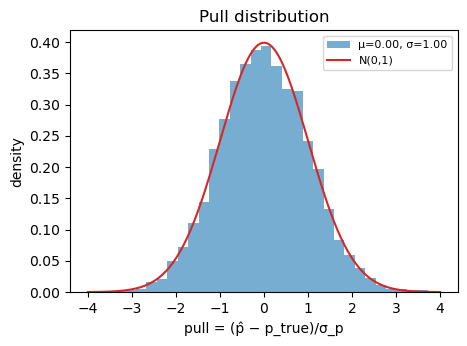

In [15]:
# ── 9a. Monte-Carlo over the noise realizations of one source ──
q_t, u_t = truth_qu(0.03, 30.0)
S_t = pt.stokes_vector(1.0, q_t, u_t)
pulls = []
for _ in range(2000):
    bfs = []
    for a in ANGLES8:
        Io, Ie = pt.oe_intensities(S_t, a)
        fo = rng.poisson(Io*3.0e5); fe = rng.poisson(Ie*3.0e5)
        bfs.append(BeamFlux(a, fo, fe, np.sqrt(max(fo, 1)), np.sqrt(max(fe, 1))))
    B = pt.lsq_modulation(bfs)
    pulls += [(B["q"]-q_t)/B["sigma_q"], (B["u"]-u_t)/B["sigma_u"]]
pulls = np.array(pulls)
print(f"pull mean = {pulls.mean():+.3f},  std = {pulls.std(ddof=1):.3f}   (target 0, 1)")
ax = pplt.plot_pull_histogram(pulls); plt.show()

# ─── Step 10: CMOS detector hardening ───

The QHY268M is a **CMOS** sensor, so the photometric error model carries the
CMOS-specific corrections described in
`docs/polarimetry/07_cmos_error_model.md`. The aperture
CCD equation used by `measure_fluxes` is

$$
\sigma^2=\underbrace{F_{\rm src}}_{\rm shot}
+\underbrace{n_{\rm ap}\,b+\textstyle\sum_{\rm ap}\sigma_{{\rm RON},i}^2}_{\rm aperture}
+\underbrace{\frac{n_{\rm ap}^2}{n_{\rm sky}}\!\left(b+\langle\sigma_{\rm RON}^2\rangle\right)}_{\rm sky\ estimate}
\;\Big/\;N_{\rm eff},
$$

with three CMOS-aware pieces demonstrated below:

- **Effective $N$.** Median-combining $N$ frames suppresses the variance by
  $N_{\rm eff}=N$ (mean) or $N/(\pi/2)$ (median) (Stockmans et al. eq. 16). $N\le2$
  is exact.
- **Per-pixel read-noise map** $\sigma_{{\rm RON},i}$ (RTN / hot-pixel tail),
  not just the scalar core.
- **Bad/hot-pixel repair** before summing (critical at $N=1$, which a median
  cannot rescue), and **saturation/linearity flagging**.

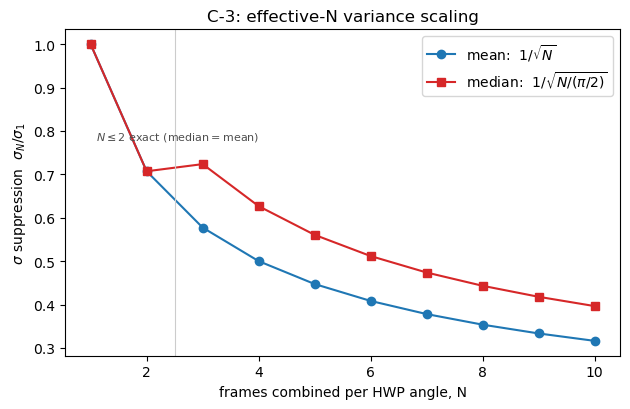

  N=2 median penalty: 2.000 (=2, exact)   N=5 median: 3.183 (=5/(pi/2))


In [16]:
# ── 10a. variance suppression by the effective number of frames ──
Ns = np.arange(1, 11)
eff_mean = np.array([_effective_n(n, "mean") for n in Ns])
eff_med  = np.array([_effective_n(n, "median") for n in Ns])

fig, ax = plt.subplots(figsize=(6.4, 4.2))
ax.plot(Ns, 1/np.sqrt(eff_mean), 'C0o-', label=r"mean:  $1/\sqrt{N}$")
ax.plot(Ns, 1/np.sqrt(eff_med),  'C3s-', label=r"median:  $1/\sqrt{N/(\pi/2)}$")
ax.axvline(2.5, color='0.8', lw=0.8)
ax.annotate(r"$N\leq2$ exact (median$=$mean)", (1.1, 0.78), fontsize=8, color='0.3')
ax.set_xlabel("frames combined per HWP angle, N")
ax.set_ylabel(r"$\sigma$ suppression  $\sigma_N/\sigma_1$")
ax.set_title("effective-N variance scaling")
ax.legend(); plt.tight_layout(); plt.show()
print(f"  N=2 median penalty: {_effective_n(2,'median'):.3f} (=2, exact)   "
      f"N=5 median: {_effective_n(5,'median'):.3f} (=5/(pi/2))")

In [17]:
# ── 10b. RON map, hot-pixel repair, and saturation on a rendered frame ──
pos = (256.0, 230.0); dx, dy = cfg.beam.offset_xy(); e_xy = (pos[0]+dx, pos[1]+dy)
demo = pt.render_frame(pt.make_scene([pos], [(1.0, q_in, u_in, 0.0)], [4.0e6]),
                       cfg, 0.0, exptime_s=EXPTIME, seeing_arcsec=SEEING,
                       sky_e_per_px=SKY_E, rng=np.random.default_rng(1), shape=(512, 512),
                       bias_adu=BIAS).astype(float)

# constant RON map reproduces the scalar exactly; an RTN patch raises sigma
_, s_scalar = pt.measure_fluxes(demo, [pos], cfg, r_ap=R_AP, r_in=R_IN, r_out=R_OUT)
ron_map = np.full(demo.shape, cfg.read_noise_e); ron_map[222:239, 248:265] = 30.0
_, s_hot_ron = pt.measure_fluxes(demo, [pos], cfg, r_ap=R_AP, r_in=R_IN, r_out=R_OUT,
                                 ron_map=ron_map)
print(f"RON map:    scalar sigma_o = {s_scalar[0]:.1f} e-;  with RTN patch = {s_hot_ron[0]:.1f} e-  "
      f"(+{100*(s_hot_ron[0]/s_scalar[0]-1):.0f}% )")

# a 60 kADU hot pixel inflates the N=1 flux; the mask repairs it
f_clean, _ = pt.measure_fluxes(demo, [pos], cfg, r_ap=R_AP, r_in=R_IN, r_out=R_OUT)
hot = demo.copy(); hot[233, 259] = 60000.0
f_hot, _ = pt.measure_fluxes(hot, [pos], cfg, r_ap=R_AP, r_in=R_IN, r_out=R_OUT)
mask = np.zeros(demo.shape, bool); mask[233, 259] = True
f_fix, _ = pt.measure_fluxes(hot, [pos], cfg, r_ap=R_AP, r_in=R_IN, r_out=R_OUT,
                             bad_pixel_mask=mask)
print(f"px repair:  flux_o clean={f_clean[0]:.3e}  hot={f_hot[0]:.3e} "
      f"(+{100*(f_hot[0]/f_clean[0]-1):.1f}%)  repaired={f_fix[0]:.3e} "
      f"({100*(f_fix[0]/f_clean[0]-1):+.1f}%)")

# a saturating core is flagged on the BeamFlux
sat_frame = np.full((512, 512), BIAS+SKY_E); sat_frame[226:235, 252:261] = 60000.0
bf = pt.measure_pair(sat_frame, pos, e_xy, cfg, hwp_deg=0.0, r_ap=R_AP, r_in=R_IN, r_out=R_OUT)
print(f"sat flag:   saturating core -> BeamFlux.saturated = {bf.saturated}  "
      f"(peak {(60000.0-BIAS)*sensor.gain_e_per_adu:.0f} e- >= sat limit {cfg.sat_limit_e():.0f} e-)")

RON map:    scalar sigma_o = 1421.4 e-;  with RTN patch = 1508.9 e-  (+6% )
px repair:  flux_o clean=1.955e+06  hot=2.003e+06 (+2.5%)  repaired=1.955e+06 (-0.0%)
sat flag:   saturating core -> BeamFlux.saturated = True  (peak 59000 e- >= sat limit 51000 e-)


# ─── Final summary ───

In [18]:
print("=" * 70)
print("  POLITE POLARIMETRY SIMULATOR SHOWCASE — SUMMARY")
print("=" * 70)
print(f"  Detector:        {sensor.sensor_name} {sensor.nx}x{sensor.ny}, "
      f"{cfg.read_noise_e} e- RON, {cfg.full_well_e:.0f} e- FWC")
print(f"  Sequence:        {len(ANGLES8)} HWP angles -> {len(paths)} FITS frames in {OUT_FITS}/")
print(f"  Sources:         {len(positions)} ({len(science)} science + {len(unpol)} unpol std + 1 pol std)")
print(f"  Calibration:     IP ({q0:+.4f},{u0:+.4f}) vs injected*eff "
      f"({EFF_TRUE*IP_TRUE[0]:+.4f},{EFF_TRUE*IP_TRUE[1]:+.4f}); eff {eff:.3f} vs {EFF_TRUE}")
print(f"  MC pull:         mean {pulls.mean():+.3f}, std {pulls.std(ddof=1):.3f}  (target 0,1)")
print("  Recovered polarization (MAS-debiased):")
for nm, p_true, th_true, s in rows:
    ok = "OK" if abs(s['p_mas']-p_true) <= 3*s['sigma_p'] else "  "
    print(f"    {ok} {nm:16s} p={s['p_mas']:.3%} {pm}{s['sigma_p']:.3%} "
          f"(inj {p_true:.3%}),  theta={s['theta_deg']:6.2f} deg (inj {th_true:.1f})")
print("=" * 70)
print("  Methods: Mueller fwd model (Masiero 2007/DUSTPol), LSQ modulation default")
print("  (Magalhaes 1984/SOLVEPOL; double-ratio bad-flat fallback, Tinbergen 1996),")
print("  MAS debias (Plaszczynski 2014/Montier II), NK&C 1993 sigma_theta,")
print("  CMOS error model (Stockmans et al.; reduction.md).  Sources A/B only.")
print("=" * 70)

  POLITE POLARIMETRY SIMULATOR SHOWCASE — SUMMARY
  Detector:        QHY268M 512x512, 3.5 e- RON, 51000 e- FWC
  Sequence:        8 HWP angles -> 8 FITS frames in FITSDATA/SIM_20260608/
  Sources:         8 (5 science + 2 unpol std + 1 pol std)
  Calibration:     IP (+0.0038,-0.0029) vs injected*eff (+0.0039,-0.0029); eff 0.965 vs 0.97
  MC pull:         mean +0.001, std 0.997  (target 0,1)
  Recovered polarization (MAS-debiased):
    OK stellar_eps_aur  p=2.994% ±0.024% (inj 3.000%),  theta= 29.74 deg (inj 30.0)
    OK ism_dust         p=1.538% ±0.026% (inj 1.500%),  theta=119.87 deg (inj 120.0)
    OK asteroid         p=0.501% ±0.020% (inj 0.500%),  theta= 73.96 deg (inj 75.0)
    OK supernova        p=0.304% ±0.019% (inj 0.300%),  theta=159.97 deg (inj 160.0)
    OK sne_faint        p=0.607% ±0.114% (inj 0.500%),  theta= 41.08 deg (inj 45.0)
  Methods: Mueller fwd model (Masiero 2007/DUSTPol), LSQ modulation default
  (Magalhaes 1984/SOLVEPOL; double-ratio bad-flat fallback, Tinberg

# ─── Appendix: Reducing a *real* observation night with `poltools` ───

Everything above ran on simulated frames. This is the recipe for a real night in
`FITSDATA/YYYYMMDD/` containing **darks**, **sky flats**, and **science HWP
sequences** (plus standard-star sequences), mirroring the basic CCD/CMOS
reductions already done in this project (`reduction.ipynb`). Stage by stage:

| # | Stage | Function(s) | What happens |
|---|---|---|---|
| 1 | **Inventory the night** | `glob` + `IMAGETYP`/`OBJECT` cards; `pt.group_by_filter`, `pt.group_by_hwp_angle` | Split FITS into darks / flats / lights; lights into per-object HWP sequences. `HWPANG` missing → hard error (fail-closed). |
| 2 | **Master calibration frames** | `caltools.master_bias`, `caltools.master_dark`, `caltools.master_flat` | Median-combined masters (`memmap=False` handles `BZERO=32768`). One **unit-median master skyflat per EFW band** — the α-BBO split is dispersive, and the LSQ default *requires* the flat (PRNU does not cancel in the fit). |
| 3 | **Clean & normalize each science frame** | `pt.read_pol_frame` → `(raw − B − D)/F` → write `*_cal.fits` | Bias+dark removed, PRNU divided out; the polarimetry header block (`HWPANG`, `FILTER`, `INSTROT`, …) is preserved so grouping still works. Calibrated frames have **no bias pedestal** → pass `bias_adu=0.0` downstream. |
| 4 | **Prep for reduction** | `PolConfig` (+ `FilterConfig` registry), `caltools.read_noise_map`, `caltools.warm_pixel_map` | The night's instrument truth: **measured** per-band `BEAMSEP`/`BEAMPA`, gain/RON for the readout mode, per-pixel RON map and hot-pixel mask, `exclude_regions` for the Savart chipped corner. |
| 5 | **Reduction** (detect → pair → photometer → modulate) | `pt.reduce_to_stokes` | One call per sequence: groups by filter then HWP angle (repeats at one angle are median-combined, effective-N tracked), DAOStarFinder + o/e pairing via the band's beam offset, aperture photometry with the CCD equation, then the **LSQ modulation fit (default)** — or `method="double_ratio"` **if the night's skyflats are bad** (it cancels flat-field errors exactly, needs HWP {0, 22.5, 45, 67.5}°). |
| 6 | **Calibration from standards** | `cal.fit_instrumental_polarization`, `cal.apply_ip`, `cal.fit_efficiency`, `cal.fit_pa_zeropoint` → `pt.PolCalibration` | Reduce the standard sequences *uncalibrated* first; fit IP $(q_0,u_0)$ from unpolarized standards, efficiency $\eta$ and PA zero-point $\Delta\theta$ from polarized standards; bundle into a `PolCalibration` and re-run the science reduction with `calibration=`. |
| 7 | **Stokes extraction** | `pt.assemble_stokes` (called inside `reduce_to_stokes`) | Calibrated $(q,u) \to p,\ \theta$ per source per band, returned as `StokesResult`. |
| 8 | **Errors / done** | `scalar_summary` of each result | $\sigma_q,\sigma_u$ (+ covariance), $\sigma_p$, **MAS-debiased** `p_mas` (Plaszczyński 2014), $\sigma_\theta$ (Gaussian high-SNR / NK&C 1993 low-SNR), LSQ $\chi^2$/dof and residual $\sigma_P$, plus saturation flags in `metadata`. |

The code cell below is the night-reduction template: it defines `reduce_night()`
implementing stages 1–8 and runs it only if the night directory exists (so this
notebook stays executable end-to-end without real data).

In [19]:
# ── Appendix: real-night reduction template — FITSDATA/YYYYMMDD -> StokesResults ──
from pathlib import Path
from collections import defaultdict
import caltools as ct


def reduce_night(night_dir, cfg_night, *,
                 unpol_std_objects, polstd_objects,   # OBJECT card values
                 p_lit, theta_lit=None,               # literature p (and PA) per pol std
                 method="lsq",        # project default; "double_ratio" if bad flats
                 r_ap=13.0, r_in=18.0, r_out=29.0, exclude_regions=None):
    """Stages 1-8: raw night FITS -> cleaned/normalized -> reduced -> calibrated Stokes.

    method="lsq" (default) requires the skyflat division in stage 3 — PRNU does
    not cancel in the modulation fit. If the night's skyflats are
    unusable, pass method="double_ratio": flat-field-independent by construction
    (needs HWP {0, 22.5, 45, 67.5} deg).
    """
    night = Path(night_dir)

    # ── 1. inventory the night by IMAGETYP: bias / dark / skyflat / science ──
    kinds = defaultdict(list)
    for p in sorted(night.glob("*.fit*")):
        t = str(fits.getheader(p).get("IMAGETYP", "LIGHT")).upper()
        kind = ("BIAS" if "BIAS" in t else "DARK" if "DARK" in t
                else "FLAT" if "FLAT" in t else "LIGHT")
        kinds[kind].append(str(p))
    if not kinds["LIGHT"]:
        raise ValueError(f"{night}: no science (LIGHT) frames found")

    # ── 2. master calibration frames (ADU; caltools uses memmap=False -> BZERO ok) ──
    B = ct.master_bias(kinds["BIAS"])                       # median master bias
    darks_by_exp = defaultdict(list)
    for p in kinds["DARK"]:
        darks_by_exp[float(fits.getheader(p)["EXPTIME"])].append(p)
    dark_exp = max(darks_by_exp)                            # longest dark set
    D = ct.master_dark(darks_by_exp[dark_exp], bias=B)      # bias-subtracted
    F = {band: ct.master_flat(fpaths, bias=B, normalize=True)   # unit median, per band
         for band, fpaths in pt.group_by_filter(kinds["FLAT"]).items()}

    # ── 3. clean + normalize each science frame -> night/calibrated/*.fits ──
    cal_dir = night / "calibrated"; cal_dir.mkdir(exist_ok=True)
    lights_by_obj = defaultdict(list)
    for p in kinds["LIGHT"]:
        data, _hwp, hdr = pt.read_pol_frame(p)              # float ADU, BZERO applied
        band = str(hdr.get("FILTER", "UNKNOWN")).strip()
        exptime = float(hdr.get("EXPTIME", hdr.get("EXPOSURE")))
        sub = data - B - D * (exptime / dark_exp)           # bias + scaled dark off
        if band in F:
            clean = sub / F[band]                           # PRNU divided out
        elif method == "double_ratio":
            clean = sub      # no skyflat for this band: only double_ratio tolerates it
        else:
            raise ValueError(f"no skyflat for {band!r}: take flats or "
                             f"use method='double_ratio'")
        for kw in ("BZERO", "BSCALE"):     # float data out: no integer rescale on write
            hdr.pop(kw, None)
        hdr["CALSTAT"] = ("BDF", "bias/dark subtracted, flat-fielded")
        out = cal_dir / (Path(p).stem + "_cal.fits")
        fits.PrimaryHDU(data=clean.astype(np.float32), header=hdr
                        ).writeto(out, overwrite=True)      # pol header block kept
        lights_by_obj[str(hdr.get("OBJECT", "UNKNOWN")).strip()].append(str(out))

    # ── 4. prep: per-pixel RON map + hot-pixel mask from the masters ──
    ron_adu, _ = ct.read_noise_map(ct.load_cube(kinds["BIAS"]))
    ron_e = ron_adu * cfg_night.sensor.gain_e_per_adu
    warm = ct.warm_pixel_map({dark_exp: darks_by_exp[dark_exp]}, bias=B,
                             config=cfg_night.sensor)
    bad_mask = warm.maps[f"warm_mask_{dark_exp}s"].astype(bool)

    def _reduce(seq_paths, calibration=None):
        # 5/7/8: detect + o/e pair -> photometry -> modulation -> Stokes + errors
        return pt.reduce_to_stokes(
            seq_paths, cfg_night, detect=True, method=method,
            calibration=calibration, estimator="mas",
            r_ap=r_ap, r_in=r_in, r_out=r_out,
            bias_adu=0.0,                       # pedestal removed in stage 3
            ron_map=ron_e, bad_pixel_mask=bad_mask, exclude_regions=exclude_regions,
        )

    def _brightest(obj):
        # standard = the highest-intensity pair detected in the standard field
        return max(_reduce(lights_by_obj[obj]),
                   key=lambda r: r.scalar_summary["I"]).scalar_summary

    # ── 6. calibration from the standards (reduced uncalibrated first) ──
    stds_u = [_brightest(o) for o in unpol_std_objects]
    q0, u0, _cov = cal.fit_instrumental_polarization(
        [s["q"] for s in stds_u], [s["u"] for s in stds_u])
    p_m, p_l, th_m, th_l = [], [], [], []
    for o in polstd_objects:
        s = _brightest(o)
        qi, ui = cal.apply_ip(s["q"], s["u"], q0, u0)
        p_m.append(float(np.hypot(qi, ui))); p_l.append(p_lit[o])
        if theta_lit is not None:
            th_m.append(np.degrees(np.arctan2(ui, qi)) / 2.0 % 180.0)
            th_l.append(theta_lit[o])
    eta = cal.fit_efficiency(p_m, p_l)
    dth = cal.fit_pa_zeropoint(th_m, th_l)[0] if theta_lit is not None else 0.0
    calib = pt.PolCalibration(q0=q0, u0=u0, dtheta_deg=dth, efficiency=eta)

    # ── science sequences with the calibration applied -> done ──
    std_set = set(unpol_std_objects) | set(polstd_objects)
    results = []
    for obj in sorted(o for o in lights_by_obj if o not in std_set):
        results += _reduce(lights_by_obj[obj], calibration=calib)
    return results, calib


# ── guarded run: executes only when a real night is on disk ──
NIGHT = Path("FITSDATA/20260701")            # <- point at a real observation night
if NIGHT.exists():
    cfg_night = cfg     # replace with the night's PolConfig (measured per-band
                        # BEAMSEP/BEAMPA from flats/standards, RON/gain per mode)
    results_night, calib_night = reduce_night(
        NIGHT, cfg_night,
        unpol_std_objects=["HD 212311"],     # Schmidt, Elston & Lupie 1992 (Source B)
        polstd_objects=["HD 204827"],
        p_lit={"HD 204827": 0.05322},        # V band; verify per observed band
        theta_lit={"HD 204827": 58.73},
        method="lsq",                        # "double_ratio" if tonight's flats are bad
    )
    print(f"calibration: IP=({calib_night.q0:+.4f},{calib_night.u0:+.4f})  "
          f"eta={calib_night.efficiency:.3f}  dtheta={calib_night.dtheta_deg:+.2f} deg")
    for r in results_night:
        s = r.scalar_summary
        print(f"  {r.name:14s} [{r.metadata['filter']}]  "
              f"p={s['p_mas']:.3%} {pm} {s['sigma_p']:.3%}   "
              f"theta={s['theta_deg']:6.2f} {pm} {s['sigma_theta_deg']:.2f} deg   "
              f"SNR {s['snr']:.1f}")
else:
    print(f"  {NIGHT}/ not on disk — reduce_night() defined above; point NIGHT at a "
          f"real FITSDATA/YYYYMMDD (darks + skyflats + science) to run stages 1-8.")

  FITSDATA/20260701/ not on disk — reduce_night() defined above; point NIGHT at a real FITSDATA/YYYYMMDD (darks + skyflats + science) to run stages 1-8.
